consider log MSE

In [1]:
from importlib import reload
import experiments_utils

reload(experiments_utils)
from experiments_utils import *

C:\Users\yilu2\my_files\research\FELsim\backend
C:\Users\yilu2\my_files\research\FELsim\backend


<module 'experiments_utils' from 'C:\\Users\\yilu2\\my_files\\research\\FELsim\\experiment\\step_2\\experiments_utils.py'>

In [6]:
CURRENT_BOUNDS = (0.01, 1.5)
EPSILON = 1e-3

REF_I_1 = 0.8218
REF_I_3 = 1.0430
REF_I = [REF_I_1, REF_I_3]

# parameter setting
N_RUNS_A = 3
A_BEAMLINE_LEN = 10

METHODS_A = [
    ("Nelder-Mead", None),
    ("L-BFGS-B", "2-point"),
    ("SLSQP", "2-point"),
    ("COBYLA", None),
    ("trust-constr", "2-point"),
]

A_VARS = {
    1: ["I", "current", lambda x: x],
    3: ["I2", "current", lambda x: x],
}
A_OBJ = {
    8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
}



In [7]:
# this is default version
METHOD_OPTIONS = {
    "L-BFGS-B": {
        "maxcor": 10,
        "ftol": 2.220446049250313e-09,
        "gtol": 1e-5,
        "eps": 1e-8,
        "maxfun": 15000,
        "maxiter": 15000,
        "maxls": 20,
    },
    "SLSQP": {
        "maxiter": 100,
        "ftol": 1e-6,
        "iprint": 1,
        "disp": False,
        "eps": 1.4901161193847656e-08,
        "finite_diff_rel_step": None,
        "workers": None,
    },
    "trust-constr": {
        "xtol": 1e-8,
        "gtol": 1e-8,
        "barrier_tol": 1e-8,
        "sparse_jacobian": None,
        "maxiter": 1000,
        "verbose": 0,
        "finite_diff_rel_step": None,
        "initial_constr_penalty": 1.0,
        "initial_tr_radius": 1.0,
        "initial_barrier_parameter": 0.1,
        "initial_barrier_tolerance": 0.1,
        "factorization_method": None,
        "disp": False,
        "workers": None,
    },
    "Nelder-Mead": {
        "maxiter": None,
        "maxfev": None,
        "disp": False,
        "return_all": False,
        "initial_simplex": None,
        "xatol": 1e-4,
        "fatol": 1e-4,
        "adaptive": False,
    },
    "COBYLA": {
        "rhobeg": 1.0,
        "tol": 1e-4,
        "maxiter": 1000,
        "disp": 0,
        "catol": None,
        "f_target": float("-inf"),
    },
}

use_log: True

▶ Scenario A — Nelder-Mead  (3 runs)
  Nelder-Mead             run 1/3  MSE=1.335e-17  nit=72  nfev=142  t=33.77s
  Nelder-Mead             run 2/3  MSE=1.659e-17  nit=75  nfev=149  t=33.02s
  Nelder-Mead             run 3/3  MSE=8.446e-18  nit=85  nfev=161  t=36.30s

▶ Scenario A — L-BFGS-B+jac  (3 runs)
  L-BFGS-B                run 1/3  MSE=4.197e-13  nit=24  nfev=297  t=68.32s
  L-BFGS-B                run 2/3  MSE=2.392e-13  nit=27  nfev=393  t=122.87s
  L-BFGS-B                run 3/3  MSE=5.732e-14  nit=21  nfev=312  t=90.70s

▶ Scenario A — SLSQP+jac  (3 runs)
  SLSQP                   run 1/3  MSE=1.869e-11  nit=25  nfev=117  t=24.65s
  SLSQP                   run 2/3  MSE=6.972e-11  nit=22  nfev=101  t=21.53s
  SLSQP                   run 3/3  MSE=1.041e-11  nit=24  nfev=115  t=26.33s

▶ Scenario A — COBYLA  (3 runs)
  COBYLA                  run 1/3  MSE=4.191e-05  nit=-1  nfev=530  t=113.45s
  COBYLA                  run 2/3  MSE=1.100e-04  nit=-1  nfev=444  

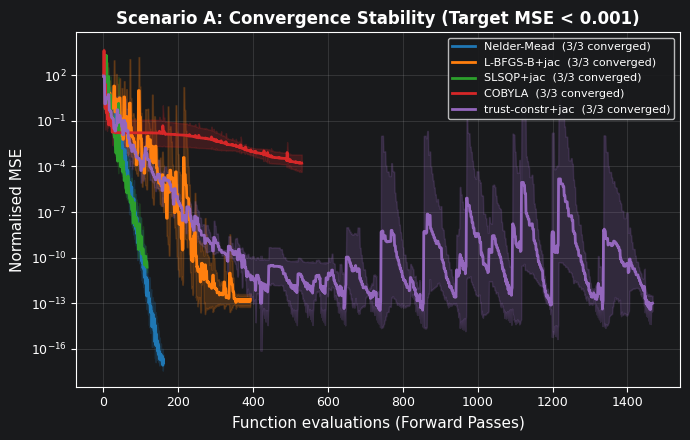

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            8.4464e-18     0.8552     1.1308
  L-BFGS-B+jac           5.7317e-14     0.8552     1.1308
  SLSQP+jac              1.0407e-11     0.8552     1.1308
  COBYLA                 4.1910e-05     0.2679     0.2576
  trust-constr+jac       3.1288e-14     0.9409     1.1785

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=8.4464e-18
    I=0.85521 A,  I2=1.13079 A


In [8]:
use_log = True
use_epsilon = 2e-13
results_A, df_A, final_summary = run_scenario_A(CURRENT_BOUNDS, EPSILON, N_RUNS_A, REF_I, A_OBJ, A_VARS, A_BEAMLINE_LEN, METHODS_A,scale="log",METHOD_OPTIONS=METHOD_OPTIONS,use_log=use_log, use_epsilon=use_epsilon)
display_results(results_A, REF_I)

use_log: False

▶ Scenario A — Nelder-Mead  (3 runs)
  Nelder-Mead             run 1/3  MSE=4.417e-09  nit=40  nfev=79   t=16.15s
  Nelder-Mead             run 2/3  MSE=6.972e-09  nit=44  nfev=89   t=14.59s
  Nelder-Mead             run 3/3  MSE=4.041e-09  nit=51  nfev=96   t=15.88s

▶ Scenario A — L-BFGS-B+jac  (3 runs)
  L-BFGS-B                run 1/3  MSE=5.397e-13  nit=13  nfev=57   t=9.72s
  L-BFGS-B                run 2/3  MSE=1.376e-12  nit=13  nfev=57   t=9.96s
  L-BFGS-B                run 3/3  MSE=7.117e-13  nit=11  nfev=48   t=9.72s

▶ Scenario A — SLSQP+jac  (3 runs)
  SLSQP                   run 1/3  MSE=3.582e-09  nit=15  nfev=49   t=12.64s
  SLSQP                   run 2/3  MSE=3.718e-08  nit=12  nfev=40   t=9.95s
  SLSQP                   run 3/3  MSE=3.414e-07  nit=10  nfev=32   t=7.34s

▶ Scenario A — COBYLA  (3 runs)
  COBYLA                  run 1/3  MSE=1.170e-05  nit=-1  nfev=236  t=42.74s
  COBYLA                  run 2/3  MSE=4.902e-05  nit=-1  nfev=584  t=99.8

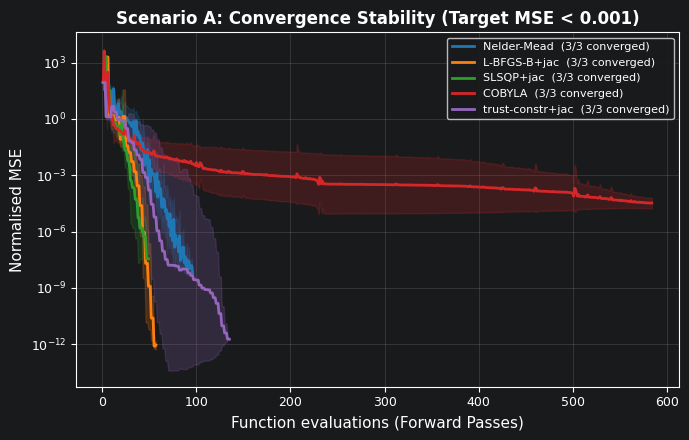

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            4.0405e-09     0.8553     1.1308
  L-BFGS-B+jac           5.3974e-13     0.8552     1.1308
  SLSQP+jac              3.5818e-09     0.7443     0.5785
  COBYLA                 1.1702e-05     0.2737     0.2628
  trust-constr+jac       1.7481e-12     0.8552     1.1308

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: L-BFGS-B+jac,  MSE=5.3974e-13
    I=0.85521 A,  I2=1.13079 A


In [9]:
# in comparison, we don't use log of MSE
use_log=False
results_A, df_A, final_summary = run_scenario_A(CURRENT_BOUNDS, EPSILON, N_RUNS_A, REF_I, A_OBJ, A_VARS, A_BEAMLINE_LEN, METHODS_A,scale="log",METHOD_OPTIONS=METHOD_OPTIONS,use_log=use_log)
display_results(results_A, REF_I)

In [ ]:
# save the results
experiment_save_path = os.path.join(CURRENT_DIR, "../results/scenario_A_results_v4.pkl")
save_results(results_A, df_A, final_summary, experiment_save_path)

In [5]:
# load the results
experiment_save_path = os.path.join(CURRENT_DIR, "../results/scenario_A_results_v4.pkl")
results_A, df_A, final_summary = load_results(experiment_save_path)

✓ experiment results loaded from c:\Users\yilu2\my_files\research\FELsim\experiment\../results/scenario_A_results_v4.pkl


give the **(alpha_x,alpha_y) scatter plot** and **MSE heatmap with iteration trajectories**

In [12]:
import importlib, experiments_utils
importlib.reload(experiments_utils)
from experiments_utils import *

c:\Users\yilu2\my_files\research\FELsim\backend


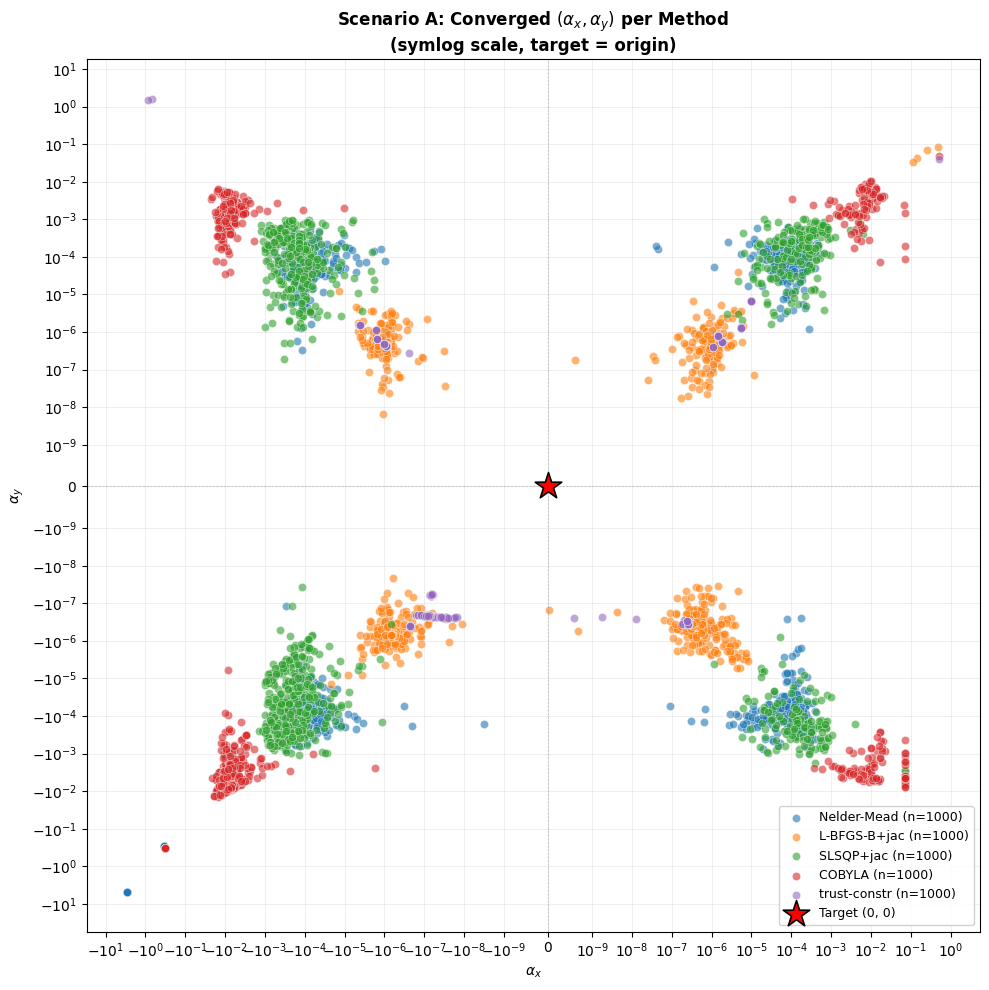

In [6]:
# scatter plot
# parameter setting

plot_MSE(df_A)

  row 5/500   349s
  row 10/500   714s
  row 15/500   1360s
  row 20/500   1742s
  row 25/500   2113s
  row 30/500   2471s
  row 35/500   2842s
  row 40/500   3225s
  row 45/500   3596s
  row 50/500   3978s
  row 55/500   4363s
  row 60/500   4760s
  row 65/500   5141s
  row 70/500   5506s
  row 75/500   5873s
  row 80/500   6279s
  row 85/500   6829s
  row 90/500   7311s
  row 95/500   7810s
  row 100/500   8310s
  row 105/500   9031s
  row 110/500   9809s
  row 115/500   10609s
  row 120/500   11380s
  row 125/500   12050s
  row 130/500   12817s
  row 135/500   13215s
  row 140/500   13616s
  row 145/500   14005s
  row 150/500   14385s
  row 155/500   14755s
  row 160/500   15123s
  row 165/500   15492s
  row 170/500   15861s
  row 175/500   16230s
  row 180/500   16598s
  row 185/500   16967s
  row 190/500   17336s
  row 195/500   17711s
  row 200/500   18080s
  row 205/500   18452s
  row 210/500   18821s
  row 215/500   19190s
  row 220/500   19559s
  row 225/500   19928s
  row 230

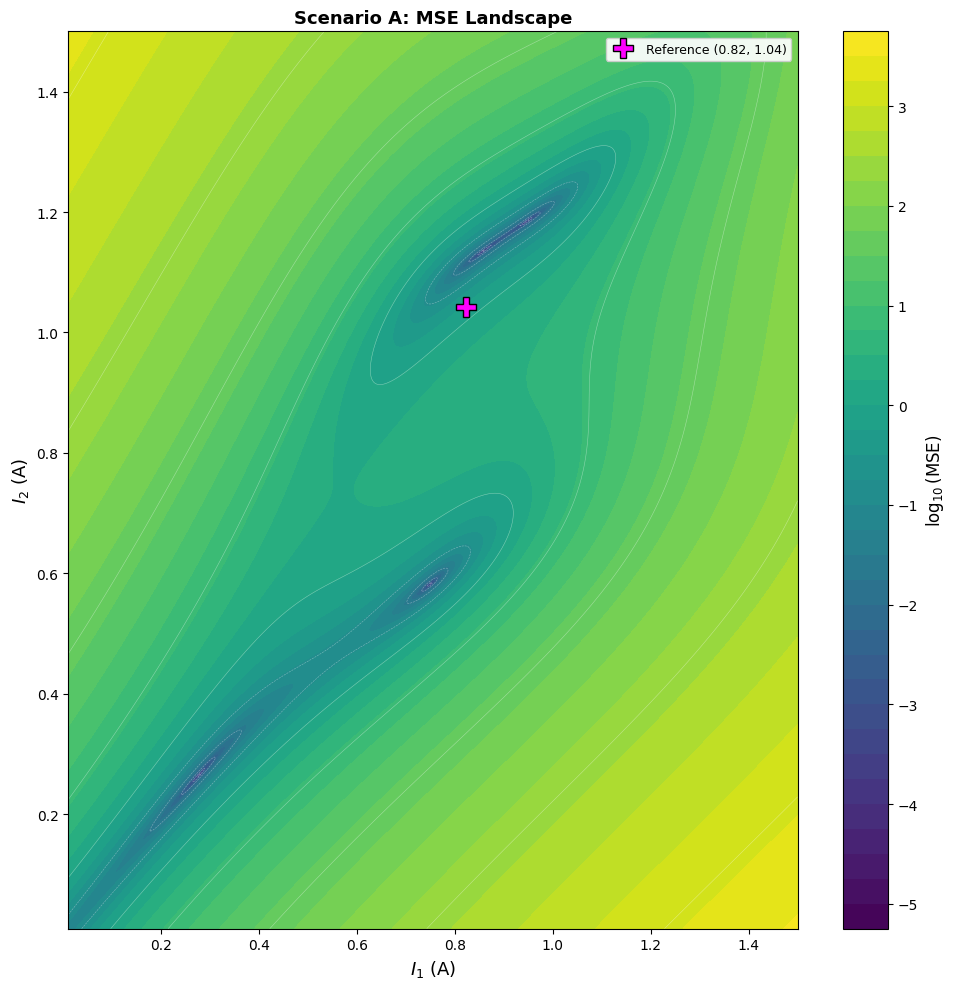

In [7]:
# save the landscape information
N_GRID = 500
landscape_save_path = os.path.join(CURRENT_DIR, "../results/scenario_A_landscape_v4.pkl")
save_landscape(CURRENT_BOUNDS,  A_BEAMLINE_LEN, A_VARS, A_OBJ, N_GRID, landscape_save_path)
plot_contour(landscape_save_path)

10 start points:
 [[0.277 0.963]
 [0.706 0.562]
 [0.539 1.188]
 [1.359 0.274]
 [0.983 0.454]
 [1.451 1.381]
 [0.957 1.132]
 [0.778 1.241]
 [0.678 0.515]
 [0.424 0.347]]
Nelder-Mead    start1 (0.28,0.96)  steps= 44  MSE=2.21e-09  x=[0.2457 0.2501]
Nelder-Mead    start2 (0.71,0.56)  steps= 26  MSE=1.97e-08  x=[0.5815 0.747 ]
Nelder-Mead    start3 (0.54,1.19)  steps= 39  MSE=2.47e-08  x=[1.1177 0.8281]
Nelder-Mead    start4 (1.36,0.27)  steps= 59  MSE=1.96e-09  x=[0.2456 0.2501]
Nelder-Mead    start5 (0.98,0.45)  steps= 33  MSE=2.98e-08  x=[0.5815 0.747 ]
Nelder-Mead    start6 (1.45,1.38)  steps= 42  MSE=3.90e-08  x=[1.1177 0.8281]
Nelder-Mead    start7 (0.96,1.13)  steps= 25  MSE=1.46e-08  x=[1.1902 0.9582]
Nelder-Mead    start8 (0.78,1.24)  steps= 30  MSE=1.65e-09  x=[1.1177 0.8281]
Nelder-Mead    start9 (0.68,0.51)  steps= 29  MSE=5.30e-08  x=[0.5815 0.747 ]
Nelder-Mead    start10 (0.42,0.35)  steps= 37  MSE=6.12e-09  x=[0.2456 0.2501]
L-BFGS-B       start1 (0.28,0.96)  steps= 11  MSE=

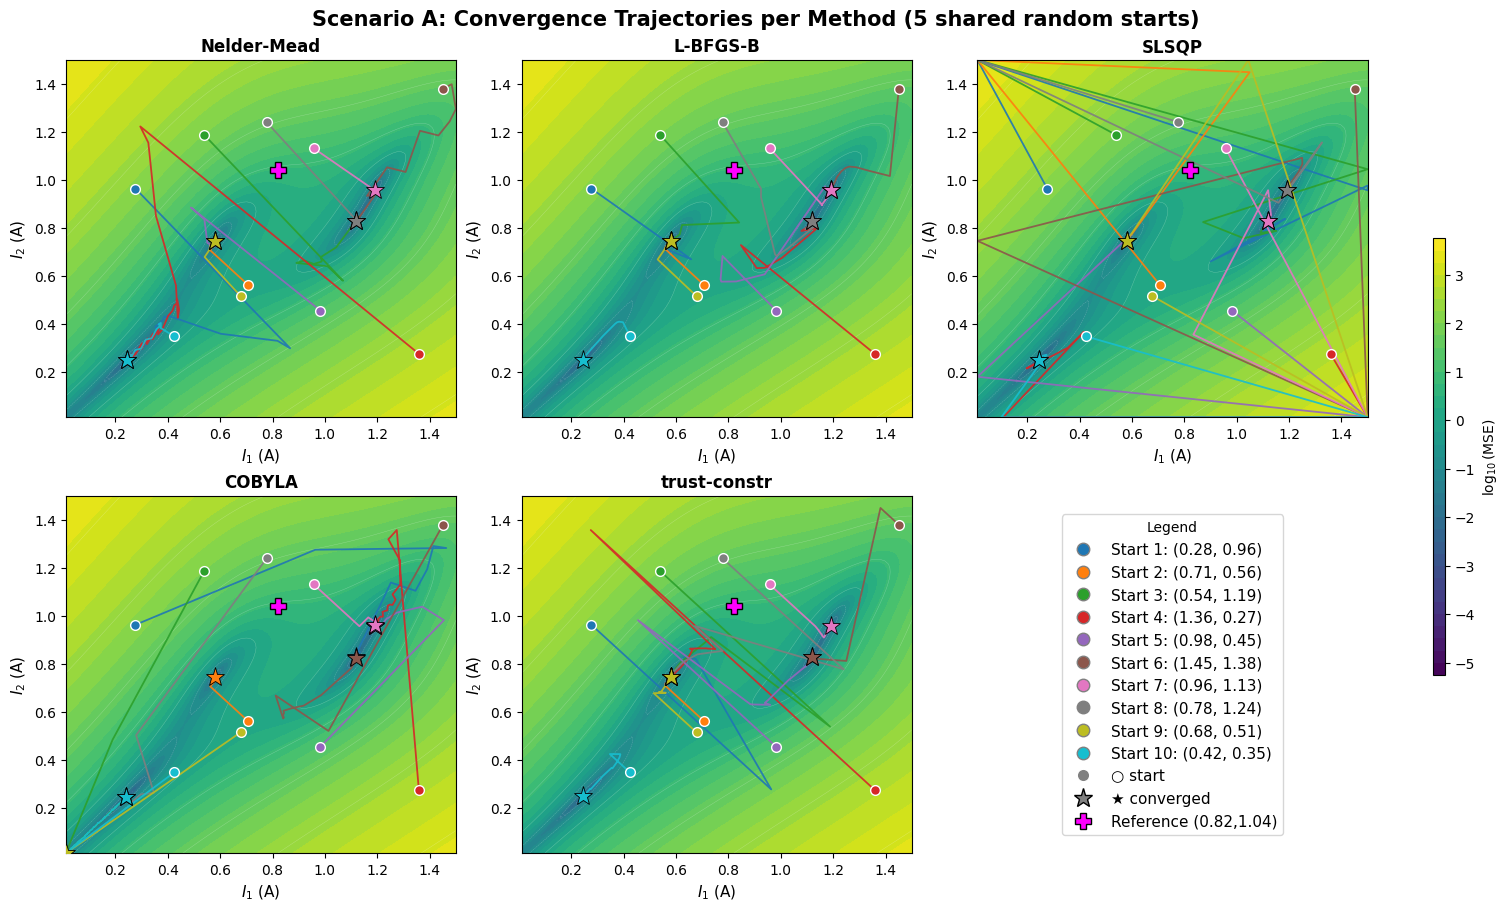

In [15]:
N_STARTS = 10
trajectories_save_path = os.path.join(CURRENT_DIR, "../results/scenario_A_trajectories_v4.pkl")
save_trajectories(A_BEAMLINE_LEN, N_STARTS, A_VARS, A_OBJ, METHODS_A, METHOD_OPTIONS, trajectories_save_path)
plot_trajectories(landscape_save_path, trajectories_save_path)